# Multiple Vehicle Two-Tower MLP
- Graces Quarters 2 ATV Dataset

## Data Loading and Preprocessing

In [2]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import multi_dataloader
importlib.reload(multi_dataloader)

from multi_dataloader import load_data, plot_gap_timeline

# 20250815_0900 is two vehicle
DATA_DIR = PROJECT_ROOT / "data" / "20250815_0900"
SENSOR_CSV = DATA_DIR / "gq_node_gps.csv"
GPS_CSV_1 = DATA_DIR / "CAR1-20250815-090042.csv"
GPS_CSV_2 = DATA_DIR / "WARTHOG3-20250815-090042.csv"
GPS_CSVS = [GPS_CSV_1, GPS_CSV_2]  # Use both vehicles' GPS data

SAMPLE_MS = 200
RESAMPLE_RATE = f"{SAMPLE_MS}ms"
CHUNK_MS = 10

node_list = sorted(pd.read_csv(SENSOR_CSV)["Node #"].astype(int).tolist())
flac_files = sorted(DATA_DIR.glob("*_respeaker.flac"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Nodes: {node_list}")
print(f"FLAC files: {len(flac_files)}")
print(f"Resampling: audio and interpolated GPS -> {RESAMPLE_RATE}")

gdf_cleaned, valid_indices, gdf_nodes = load_data(
    data_dir=DATA_DIR,
    sensor_csv=SENSOR_CSV,
    gps_csvs=GPS_CSVS,
    node_list=node_list,
    chunk_ms=CHUNK_MS,
    sample_ms=SAMPLE_MS,
    resample_rate=RESAMPLE_RATE,
    plot_gaps=False,
)

Project root: /Users/kyle/Documents/GitHub/TwoTowerSensorRec
Data dir: /Users/kyle/Documents/GitHub/TwoTowerSensorRec/data/20250815_0900
Nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
FLAC files: 10
Resampling: audio and interpolated GPS -> 200ms
Loaded FLAC: /Users/kyle/Documents/GitHub/TwoTowerSensorRec/data/20250815_0900/20250815_090042_dvpg_gq_orin_1_respeaker.flac
Loaded FLAC: /Users/kyle/Documents/GitHub/TwoTowerSensorRec/data/20250815_0900/20250815_090042_dvpg_gq_orin_2_respeaker.flac
Loaded FLAC: /Users/kyle/Documents/GitHub/TwoTowerSensorRec/data/20250815_0900/20250815_090042_dvpg_gq_orin_3_respeaker.flac
Loaded FLAC: /Users/kyle/Documents/GitHub/TwoTowerSensorRec/data/20250815_0900/20250815_090042_dvpg_gq_orin_4_respeaker.flac
Loaded FLAC: /Users/kyle/Documents/GitHub/TwoTowerSensorRec/data/20250815_0900/20250815_090042_dvpg_gq_orin_5_respeaker.flac
Loaded FLAC: /Users/kyle/Documents/GitHub/TwoTowerSensorRec/data/20250815_0900/20250815_090042_dvpg_gq_orin_6_respeaker.flac
Loaded FLAC

## Feature Engineering

In [ ]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import multi_dataloader
import audio_feature_dataloader
import multi_processed_feature_builder
importlib.reload(multi_dataloader)
importlib.reload(audio_feature_dataloader)
importlib.reload(multi_processed_feature_builder)

from multi_dataloader import load_data
from audio_feature_dataloader import build_audio_feature_dataset
from multi_processed_feature_builder import build_processed_two_tower_data, save_processed_two_tower_data, _detect_vehicles

DATA_DIR = PROJECT_ROOT / "data" / "20250815_0900"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SENSOR_CSV = DATA_DIR / "gq_node_gps.csv"
GPS_CSV_1 = DATA_DIR / "CAR1-20250815-090042.csv"
GPS_CSV_2 = DATA_DIR / "WARTHOG3-20250815-090042.csv"
GPS_CSVS = [GPS_CSV_1, GPS_CSV_2]  # Use both vehicles' GPS data

SAMPLE_MS = 200
RESAMPLE_RATE = f"{SAMPLE_MS}ms"
CHUNK_MS = 10
EXPANDED_PREFIX = "vehicle_sensor_subset_200ms_expanded_features"

context_audio_features = [
    "rms_db", "spectral_centroid_hz", "spectral_flatness",
    "band_20_120_ratio", "band_120_500_ratio", "band_500_2000_ratio",
    "low_to_voice_db", "mid_to_voice_db", "rms_delta_db", "centroid_delta_hz",
    "peak_db", "crest_factor_db", "zcr", "spectral_bandwidth_hz",
    "spectral_rolloff85_hz", "spectral_entropy", "band_20_120_db",
    "band_120_500_db", "band_500_2000_db", "band_2000_6000_db",
    "band_2000_6000_ratio", "flatness_delta",
]

action_audio_features = [
    "rms_db", "spectral_centroid_hz", "spectral_flatness",
    "band_20_120_ratio", "band_120_500_ratio", "low_to_voice_db",
    "band_500_2000_ratio", "mid_to_voice_db", "crest_factor_db", "zcr",
    "spectral_bandwidth_hz", "spectral_rolloff85_hz", "spectral_entropy",
    "band_2000_6000_ratio", "flatness_delta",
]

per_node_required = [
    "rssi_median", "rssi_mad", "rssi_iqr", "rssi_trimmed_mean",
    "rssi_persistence_top3", "rssi_persistence_top5",
    "vehicle_like_score", "construction_like_score", "vehicle_minus_construction_score",
]
global_required = [
    "rssi_top1_top3_gap", "rssi_top1_top5_gap", "global_rssi_mean",
    "global_rssi_std", "global_rssi_range",
] + [
    f"global_{stat}_{feature}"
    for feature in [
        "construction_like_score", "vehicle_like_score", "spectral_entropy",
        "crest_factor_db", "band_2000_6000_ratio",
    ]
    for stat in ["mean", "max", "std", "range"]
]
action_subset_required = [
    "subset_centroid_minus_acoustic_com_x",
    "subset_centroid_minus_acoustic_com_y",
    "subset_centroid_to_acoustic_com_dist",
    "num_signal_top2_in_subset", "num_signal_top3_in_subset", "num_signal_top5_in_subset",
    "best_signal_rank_in_subset", "mean_signal_rank_in_subset", "worst_signal_rank_in_subset",
    "median_rssi", "mad_rssi", "iqr_rssi", "range_rssi",
]
audio_agg_required = [
    f"{stat}_audio_{feature}"
    for feature in action_audio_features
    for stat in ["mean", "max", "min", "std", "range"]
]
score_agg_required = [
    f"{stat}_{feature}"
    for feature in ["construction_like_score", "vehicle_like_score", "vehicle_minus_construction_score"]
    for stat in ["mean", "max", "std"]
]

node_list = sorted(pd.read_csv(SENSOR_CSV)["Node #"].astype(int).tolist())
gdf_cleaned, valid_indices, gdf_nodes = load_data(
    data_dir=DATA_DIR,
    sensor_csv=SENSOR_CSV,
    gps_csvs=GPS_CSVS,
    node_list=node_list,
    chunk_ms=CHUNK_MS,
    sample_ms=SAMPLE_MS,
    resample_rate=RESAMPLE_RATE,
    plot_gaps=False,
)
audio_feature_df, audio_feature_long, audio_gdf_nodes = build_audio_feature_dataset(
    data_dir=DATA_DIR,
    sensor_csv=SENSOR_CSV,
    node_list=node_list,
    sample_ms=SAMPLE_MS,
    add_cross_sensor=True,
)

# Detect vehicles from merged data
seq_for_detection = gdf_cleaned.iloc[valid_indices].copy()
vehicle_list = _detect_vehicles(seq_for_detection)
print(f"Detected vehicles: {vehicle_list}")

expanded_processed = build_processed_two_tower_data(
    gdf_cleaned=gdf_cleaned,
    gdf_nodes=gdf_nodes,
    valid_indices=valid_indices,
    node_list=node_list,
    vehicle_list=vehicle_list,  # Pass all detected vehicles
    audio_feature_long=audio_feature_long,
    history_steps=5,
    max_subset_size=3,
    utility_second_weight=0.45,
    utility_third_weight=0.20,
    softmax_temperature=4.0,
    context_audio_features=context_audio_features,
    action_audio_features=action_audio_features,
    include_audio_derived_features=True,
    verbose=True,
    progress_every=1500,
)

# For multi-vehicle datasets, build_processed_two_tower_data concatenates per-vehicle
# results: sequence_df has 2*T rows and examples_df has 2*T*M rows with per-vehicle
# utilities. Deduplicate to T*M rows, summing utilities across vehicles so each
# (time_id, subset) gets u1+u2. Also preserve per-vehicle utility and closest_node as
# named columns so multi-vehicle accuracy metrics can be computed at evaluation time.
if len(vehicle_list) > 1:
    seq_df = expanded_processed["sequence_df"]
    ex_df = expanded_processed["examples_df"].copy()
    fw_df = expanded_processed["feature_wide_df"]

    # Sort so that within each (time_id, subset_str) group the vehicle ordering
    # matches vehicle_list order (build_processed_two_tower_data concatenates in order).
    ex_df = ex_df.sort_values(["time_id", "subset_str"]).reset_index(drop=True)
    ex_df["_veh_idx"] = ex_df.groupby(["time_id", "subset_str"]).cumcount()

    # For each vehicle, merge its utility and closest_node as new named columns so
    # they survive deduplication and are available for per-vehicle accuracy metrics.
    for i, vname in enumerate(vehicle_list):
        veh_rows = (
            ex_df.loc[
                ex_df["_veh_idx"] == i,
                ["time_id", "subset_str", "utility", "closest_node"],
            ]
            .rename(columns={
                "utility": f"utility_{vname}",
                "closest_node": f"closest_node_{vname}",
            })
        )
        ex_df = ex_df.merge(veh_rows, on=["time_id", "subset_str"], how="left")

    # Combined utility (u1 + u2) is the training label.
    ex_df["utility"] = ex_df[[f"utility_{v}" for v in vehicle_list]].sum(axis=1)
    ex_df = ex_df.drop(columns=["_veh_idx"])

    ex_df_unique = (
        ex_df.drop_duplicates(subset=["time_id", "subset_str"], keep="first")
        .reset_index(drop=True)
    )
    seq_df_unique = (
        seq_df.sort_values("time_id")
        .drop_duplicates(subset="time_id", keep="first")
        .reset_index(drop=True)
    )
    fw_df_unique = fw_df[~fw_df.index.duplicated(keep="first")]

    expanded_processed = dict(expanded_processed)
    expanded_processed["sequence_df"] = seq_df_unique
    expanded_processed["examples_df"] = ex_df_unique
    expanded_processed["feature_wide_df"] = fw_df_unique

    new_per_veh_cols = [c for c in ex_df_unique.columns if any(v in c for v in vehicle_list)]
    print(f"\nMulti-vehicle deduplication (utilities summed per subset):")
    print(f"  sequence_df:    {len(seq_df)} → {len(seq_df_unique)} rows")
    print(f"  examples_df:    {len(ex_df)} → {len(ex_df_unique)} rows")
    print(f"  feature_wide_df:{len(fw_df)} → {len(fw_df_unique)} rows")
    print(f"  per-vehicle columns preserved: {new_per_veh_cols}")

expanded_paths = save_processed_two_tower_data(
    expanded_processed,
    processed_dir=PROCESSED_DIR,
    prefix=EXPANDED_PREFIX,
)

meta = expanded_processed["meta"]
missing_context_audio = sorted(set(context_audio_features) - set(meta["context_audio_features"]))
missing_action_audio = sorted(set(action_audio_features) - set(meta["action_audio_features"]))
assert not missing_context_audio, missing_context_audio
assert not missing_action_audio, missing_action_audio

context_names = set(meta["context_feature_names"])
node_feature_cols = set(expanded_processed["node_feature_df"].columns)
feature_wide_cols = set(expanded_processed["feature_wide_df"].columns)
for node in meta["ordered_nodes"]:
    for feature in per_node_required:
        assert feature in node_feature_cols, f"missing node_feature_df column: {feature}"
        assert f"n{node}_{feature}" in context_names, f"missing context feature: n{node}_{feature}"
        assert f"n{node}_{feature}" in feature_wide_cols, f"missing feature_wide column: n{node}_{feature}"
    for feature in context_audio_features:
        assert f"n{node}_audio_{feature}" in context_names, f"missing context audio: n{node}_audio_{feature}"

global_names = set(meta["global_feature_names"])
for feature in global_required:
    assert feature in global_names, f"missing global context feature: {feature}"
    assert feature in feature_wide_cols, f"missing feature_wide global column: {feature}"

action_names = set(meta["action_feature_names"])
for feature in action_subset_required + audio_agg_required + score_agg_required:
    assert feature in action_names, f"missing action feature: {feature}"

arrays = np.load(expanded_paths["arrays_npz"])
assert arrays["C_by_time"].shape[1] == meta["context_dim"] == len(meta["context_feature_names"])
assert arrays["A_examples"].shape[1] == meta["action_raw_dim"] == len(meta["action_feature_names"])

leak_tokens = ("distance_to", "vehicle_x", "vehicle_y", "latitude", "longitude")
feature_names = list(meta["context_feature_names"]) + list(meta["action_feature_names"])
leaky_features = [name for name in feature_names if any(tok in name.lower() for tok in leak_tokens)]
assert not leaky_features, leaky_features[:20]

print("expanded processed prefix:", EXPANDED_PREFIX)
print("context_dim:", meta["context_dim"])
print("action_dim:", meta["action_raw_dim"])
print("times/examples:", meta["num_times"], meta["num_examples"])
print("all requested expanded features are present; no feature-side vehicle coordinate leakage detected")
display(pd.DataFrame([{"artifact": k, "path": str(v)} for k, v in expanded_paths.items()]))


## Model Training

In [7]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.multi_two_tower_training import (  # noqa: E402
    TrainConfig,
    compare_on_common_objectives,
    load_processed_two_tower_data,
    summarize_results,
    train_one_config,
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PREFIX = "vehicle_sensor_subset_200ms_expanded_features"
OUT_DIR = PROJECT_ROOT / "experiments" / "static_action_two_tower"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DEVICE: {DEVICE}")

# Load the full expanded dataset, then remove all live/time-varying columns from A_examples.
data = load_processed_two_tower_data(PROCESSED_DIR, prefix=PREFIX, utility_name="saved")
meta = data["meta"]
action_names = list(meta["action_feature_names"])
examples_index = data["examples_index"]

mask_names = [name for name in action_names if name.startswith("mask_n")]
canonical_slot_names = []
for slot in (1, 2, 3):
    canonical_slot_names.extend([
        f"slot{slot}_sensor_x_norm",
        f"slot{slot}_sensor_y_norm",
    ])
geometry_names = [
    "pairwise_dist_1_m",
    "pairwise_dist_2_m",
    "pairwise_dist_3_m",
    "subset_centroid_x_norm",
    "subset_centroid_y_norm",
    "subset_max_spread_m",
    "subset_triangle_area_norm",
    "subset_size",
]
static_action_names = mask_names + canonical_slot_names + geometry_names

missing = sorted(set(static_action_names) - set(action_names))
if missing:
    raise ValueError(f"Missing expected static action columns: {missing}")

subset_key = "subset_str" if "subset_str" in examples_index.columns else "subset"
subset_labels = examples_index[subset_key].astype(str).to_numpy()
n_unique_subsets = int(pd.Series(subset_labels).nunique())
expected_actions = int(meta.get("num_actions_per_time", len(meta.get("full_subset_universe", []))))

context_names = list(meta["context_feature_names"])
sensor_xy = {}
for node in meta["ordered_nodes"]:
    x_name = f"n{int(node)}_sensor_x_norm"
    y_name = f"n{int(node)}_sensor_y_norm"
    sensor_xy[int(node)] = (
        float(data["C_by_time"][0, context_names.index(x_name)]),
        float(data["C_by_time"][0, context_names.index(y_name)]),
    )

def parse_subset_nodes(label: str) -> list[int]:
    cleaned = str(label).replace("(", "").replace(")", "").replace(",", "-").replace(" ", "")
    return [int(part) for part in cleaned.split("-") if part]

# Rebuild slot coordinates in canonical subset order. The raw slot*_sensor_* columns
# come from the live selected-node descriptor ordering, so they drift across time.
unique_subset_labels = pd.Series(subset_labels).drop_duplicates().astype(str).tolist()
slot_lookup = {}
for label in unique_subset_labels:
    nodes = parse_subset_nodes(label)
    vals = []
    for slot_idx in range(3):
        if slot_idx < len(nodes):
            vals.extend(sensor_xy[nodes[slot_idx]])
        else:
            vals.extend([0.0, 0.0])
    slot_lookup[label] = vals
canonical_slot_matrix = np.asarray([slot_lookup[label] for label in subset_labels], dtype=np.float32)

A_static_parts = []
for name in mask_names:
    A_static_parts.append(data["A_examples"][:, action_names.index(name)].astype(np.float32))
for j, _name in enumerate(canonical_slot_names):
    A_static_parts.append(canonical_slot_matrix[:, j])
for name in geometry_names:
    A_static_parts.append(data["A_examples"][:, action_names.index(name)].astype(np.float32))
A_static = np.column_stack(A_static_parts).astype(np.float32)

# The same subset must have exactly the same action vector at every timestamp.
static_df = pd.DataFrame(A_static, columns=static_action_names)
static_df["subset_key"] = subset_labels
grouped_max = static_df.groupby("subset_key", sort=False)[static_action_names].max()
grouped_min = static_df.groupby("subset_key", sort=False)[static_action_names].min()
max_static_drift = float((grouped_max - grouped_min).to_numpy().max())
if max_static_drift > 1e-6:
    raise AssertionError(f"Static action features drift across time: max drift={max_static_drift:.3g}")

# Build the action catalog: one row per unique candidate subset.
# For multi-vehicle datasets the same subset may appear multiple times at a given
# time_id (one per vehicle before deduplication), so drop duplicates by subset_key.
first_time_id = int(examples_index["time_id"].min())
time0_rows = examples_index[examples_index["time_id"].eq(first_time_id)]
time0_unique = time0_rows.drop_duplicates(subset=subset_key)
catalog_global_idx = time0_unique.index.to_numpy()
catalog_mask = np.zeros(len(examples_index), dtype=bool)
catalog_mask[catalog_global_idx] = True
A_static_catalog = A_static[catalog_mask].astype(np.float32)
catalog_cols = [col for col in ["time_id", "subset", "subset_str", "subset_size"] if col in examples_index.columns]
action_catalog_df = examples_index.loc[catalog_mask, catalog_cols].reset_index(drop=True).copy()

if len(action_catalog_df) != n_unique_subsets:
    raise AssertionError(f"Expected one catalog row per subset, got {len(action_catalog_df)} vs {n_unique_subsets}")
if expected_actions and n_unique_subsets != expected_actions:
    raise AssertionError(f"Expected {expected_actions} actions per time, got {n_unique_subsets}")

static_meta = dict(meta)
static_meta["action_feature_names"] = static_action_names
static_meta["action_raw_dim"] = int(A_static.shape[1])
static_meta["static_action_feature_names"] = static_action_names
static_meta["static_action_source_prefix"] = PREFIX
static_meta["static_action_note"] = (
    "Action tower sees only subset membership, selected sensor coordinates, subset geometry, "
    "and subset size. All RSSI/audio/rank/acoustic-COM features remain in the context side "
    "or are removed from the action tower so action embeddings can be precomputed."
)

static_data = dict(data)
static_data["A_examples"] = A_static
static_data["meta"] = static_meta

print("\nStatic action feature check")
print(f"original action_dim: {len(action_names)}")
print(f"static action_dim:   {A_static.shape[1]}")
print(f"unique subsets:      {n_unique_subsets}")
print(f"max static drift:    {max_static_drift:.3g}")
print("static action columns:")
print(static_action_names)

config = TrainConfig(
    run_name="static_action_saved_h512_d2_e16_lr5e4_multi",
    utility_name="saved",
    hidden=512,
    emb_dim=16,
    depth=2,
    dropout=0.05,
    combine_mode="mul_only",
    loss_name="mse",
    lr=5e-4,
    weight_decay=1e-4,
    batch_size=8192,
    max_epochs=50, # 300
    patience=50, # 300
    seed=22,
    log_every=1,
    num_workers=0,
)

result = train_one_config(static_data, config, device=DEVICE, verbose=True)
summary_df = summarize_results([result])
common_eval_df = compare_on_common_objectives([result])
test_eval_df = (
    common_eval_df[common_eval_df["split"].eq("test")]
    .sort_values(["eval_objective", "avg_norm_regret", "mean_rank"])
    .reset_index(drop=True)
)

display(summary_df)
display(test_eval_df)

# Precompute exactly one embedding per candidate subset. At runtime only the context tower is live.
prepared = result["prepared"]
A_mu = prepared["standardizers"]["A_mu"]
A_sigma = prepared["standardizers"]["A_sigma"]
A_static_catalog_std = ((A_static_catalog - A_mu) / A_sigma).astype(np.float32)

model = result["model"]
model.eval()
with torch.no_grad():
    A_tensor = torch.from_numpy(A_static_catalog_std).to(result["device"])
    static_action_embeddings = model.embed_action(A_tensor).cpu().numpy().astype(np.float32)

run_dir = OUT_DIR / config.run_name
run_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = run_dir / "checkpoint.pt"
embedding_path = run_dir / "static_action_embeddings.npz"
history_path = run_dir / "history.csv"
metrics_path = run_dir / "metrics.json"
summary_path = run_dir / "summary.csv"
eval_path = run_dir / "common_eval.csv"
catalog_path = run_dir / "static_action_catalog.csv"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": asdict(config),
        "context_dim": int(prepared["C_by_time"].shape[1]),
        "action_dim": int(prepared["A_examples"].shape[1]),
        "static_action_feature_names": static_action_names,
        "standardizers": prepared["standardizers"],
        "meta": static_meta,
        "best_epoch": int(result["best_epoch"]),
    },
    checkpoint_path,
)
np.savez_compressed(
    embedding_path,
    action_embeddings=static_action_embeddings,
    action_vectors=A_static_catalog,
    action_vectors_std=A_static_catalog_std,
    subset_key=action_catalog_df[subset_key].astype(str).to_numpy() if subset_key in action_catalog_df else action_catalog_df["subset"].astype(str).to_numpy(),
    static_action_feature_names=np.array(static_action_names),
)
result["history"].to_csv(history_path, index=False)
summary_df.to_csv(summary_path, index=False)
common_eval_df.to_csv(eval_path, index=False)
action_catalog_df.to_csv(catalog_path, index=False)
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(result["metrics"], f, indent=2)

print("\nSaved static-action run")
print(f"run_dir: {run_dir}")
print(f"checkpoint: {checkpoint_path}")
print(f"static action embeddings: {embedding_path}")
print(f"embedding table shape: {static_action_embeddings.shape} = {n_unique_subsets} subsets x {config.emb_dim} dims")

PROJECT_ROOT: /Users/kyle/Documents/GitHub/TwoTowerSensorRec
DEVICE: cpu

Static action feature check
original action_dim: 218
static action_dim:   24
unique subsets:      175
max static drift:    0
static action columns:
['mask_n1', 'mask_n2', 'mask_n3', 'mask_n4', 'mask_n5', 'mask_n6', 'mask_n7', 'mask_n8', 'mask_n9', 'mask_n10', 'slot1_sensor_x_norm', 'slot1_sensor_y_norm', 'slot2_sensor_x_norm', 'slot2_sensor_y_norm', 'slot3_sensor_x_norm', 'slot3_sensor_y_norm', 'pairwise_dist_1_m', 'pairwise_dist_2_m', 'pairwise_dist_3_m', 'subset_centroid_x_norm', 'subset_centroid_y_norm', 'subset_max_spread_m', 'subset_triangle_area_norm', 'subset_size']
Multi-vehicle dataset detected: ['vehicle1']
static_action_saved_h512_d2_e16_lr5e4_multi ep 001/050* loss=0.06827 val_rmse=0.1515 top1=0.095 top3=0.202 reg=0.1605 rank=24.38 10s
static_action_saved_h512_d2_e16_lr5e4_multi ep 002/050* loss=0.01311 val_rmse=0.1357 top1=0.125 top3=0.262 reg=0.1376 rank=21.39 20s
static_action_saved_h512_d2_e16_lr5

,run_name,utility,hidden,emb_dim,depth,dropout,combine,loss,best_epoch,train_rmse,...,val_avg_regret,val_avg_norm_regret,test_rmse,test_mae,test_r2,test_top1,test_top3,test_mean_rank,test_avg_regret,test_avg_norm_regret
0,static_action_saved_h512_d2_e16_lr5e4_multi,saved,512,16,2,0.05,mul_only,mse,47,0.012968,...,0.103188,0.113188,0.108923,0.084987,0.704739,0.191698,0.393962,15.457358,0.086473,0.097975


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,static_action_saved_h512_d2_e16_lr5e4_multi,saved,contains_closest,test,512,16,mul_only,0.795472,0.795472,10.408302,0.204528,0.204528
1,static_action_saved_h512_d2_e16_lr5e4_multi,saved,rank_discount,test,512,16,mul_only,0.795472,0.795472,15.600755,0.122528,0.136143
2,static_action_saved_h512_d2_e16_lr5e4_multi,saved,saved_rational,test,512,16,mul_only,0.191698,0.393962,15.457358,0.086473,0.097975



Saved static-action run
run_dir: /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi
checkpoint: /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/checkpoint.pt
static action embeddings: /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/static_action_embeddings.npz
embedding table shape: (175, 16) = 175 subsets x 16 dims


## Epoch Selection

In [ ]:
# Future-reference training with regret-tolerant rank-based checkpoint selection.
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import copy
import json
import time

import numpy as np
import pandas as pd
import torch
from IPython.display import display

from scripts.multi_two_tower_training import (  # noqa: E402
    TwoTowerMLP,
    TrainConfig,
    build_utility_labels,
    compare_on_common_objectives,
    evaluate_split,
    make_loader,
    make_loss,
    prepare_standardized_data,
    set_all_seeds,
    summarize_results,
)

# Future-reference training cell.
# It keeps the first cell's model/training config the same, but changes best-epoch selection.
# The original helper selected by (val_avg_regret, val_rmse). That is defensible, but it
# can prefer an epoch with slightly lower regret while later epochs have better rank/top-k.
#
# New selector:
#   1. Keep any epoch within REGRET_REL_TOL of the best validation regret so far.
#   2. Within that regret-tolerant set, prefer lower mean_rank.
#   3. Then prefer higher top3, higher top1, lower normalized regret, lower RMSE.
#
# This keeps saved utility regret primary, but avoids overfitting the checkpoint choice to
# tiny regret differences when subset decision metrics are clearly better.

required_globals = [
    "static_data",
    "static_action_names",
    "A_static_catalog",
    "action_catalog_df",
    "subset_key",
    "OUT_DIR",
    "DEVICE",
    "config",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the first cell first so static_data/config/catalog variables exist. "
        f"Missing: {missing_globals}"
    )

REGRET_REL_TOL = 0.03  # 3% regret tolerance; keep regret primary, then improve decision quality.
RUN_NAME = f"{config.run_name}_regret_tol_rank_selected"
RUN_DIR = OUT_DIR / RUN_NAME
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
RUN_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Same config as first cell, except run_name so artifacts do not overwrite the original run.
select_cfg = copy.deepcopy(config)
select_cfg.run_name = RUN_NAME

print("Future-reference static-action run")
print("same hyperparameters as first cell")
print("old selector: (val_avg_regret, val_rmse)")
print(f"new selector: regret within {REGRET_REL_TOL:.1%} of best-so-far -> mean_rank -> top3 -> top1 -> norm_regret -> rmse")
print("run_dir:", RUN_DIR)


def selector_key(val: dict[str, float], best_regret_so_far: float) -> tuple[float, ...]:
    """Lower is better. Regret remains primary, but only outside a tolerance band."""
    regret = float(val["avg_regret"])
    regret_floor = best_regret_so_far * (1.0 + REGRET_REL_TOL)
    regret_penalty = max(0.0, regret - regret_floor)
    return (
        regret_penalty,
        float(val["mean_rank"]),
        -float(val["top3"]),
        -float(val["top1"]),
        float(val["avg_norm_regret"]),
        float(val["rmse"]),
    )


def save_selected_checkpoint(
    *,
    path: Path,
    epoch: int,
    key: tuple[float, ...],
    val: dict[str, float],
    model: TwoTowerMLP,
    optimizer: torch.optim.Optimizer,
    prepared: dict,
    config: TrainConfig,
    best_regret_so_far: float,
) -> None:
    torch.save(
        {
            "epoch": int(epoch),
            "selector_key": [float(x) for x in key],
            "best_regret_so_far": float(best_regret_so_far),
            "regret_rel_tol": float(REGRET_REL_TOL),
            "val_metrics": {k: float(v) for k, v in val.items()},
            "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
            "optimizer_state_dict": optimizer.state_dict(),
            "config": asdict(config),
            "context_dim": int(prepared["C_by_time"].shape[1]),
            "action_dim": int(prepared["A_examples"].shape[1]),
            "static_action_feature_names": list(static_action_names),
            "standardizers": prepared["standardizers"],
            "meta": prepared["meta"],
            "selection_rule": (
                f"avg_regret within {REGRET_REL_TOL:.1%} of best-so-far, then "
                "mean_rank, top3, top1, avg_norm_regret, rmse"
            ),
        },
        path,
    )


# Prepare data exactly as train_one_config would.
train_data = dict(static_data)
if train_data.get("utility_name") != select_cfg.utility_name or train_data.get("utility_kwargs") != (select_cfg.utility_kwargs or {}):
    train_data["y_examples"] = build_utility_labels(
        train_data["examples_index"],
        train_data["saved_y_examples"],
        train_data["meta"],
        select_cfg.utility_name,
        select_cfg.utility_kwargs or {},
    ).astype(np.float32)
    train_data["utility_name"] = select_cfg.utility_name
    train_data["utility_kwargs"] = select_cfg.utility_kwargs or {}

prepared_select = prepare_standardized_data(train_data, select_cfg)
train_loader = make_loader(prepared_select, prepared_select["split"]["train"], select_cfg, shuffle=True)

model_select = TwoTowerMLP(
    context_dim=prepared_select["C_by_time"].shape[1],
    action_dim=prepared_select["A_examples"].shape[1],
    hidden=select_cfg.hidden,
    emb_dim=select_cfg.emb_dim,
    depth=select_cfg.depth,
    dropout=select_cfg.dropout,
    combine_mode=select_cfg.combine_mode,
).to(DEVICE)

optimizer = torch.optim.AdamW(model_select.parameters(), lr=select_cfg.lr, weight_decay=select_cfg.weight_decay)
loss_fn = make_loss(select_cfg.loss_name)

set_all_seeds(select_cfg.seed)
best_state = None
best_epoch = -1
best_key = None
best_regret_so_far = float("inf")
wait = 0
history_rows = []
start_time = time.time()

for epoch in range(1, select_cfg.max_epochs + 1):
    model_select.train()
    losses = []

    for C, A, y in train_loader:
        C = C.to(DEVICE)
        A = A.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred = model_select(C, A)
        loss = loss_fn(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_select.parameters(), max_norm=5.0)
        optimizer.step()
        losses.append(float(loss.detach().cpu()))

    train_loss = float(np.mean(losses))
    val = evaluate_split(model_select, prepared_select, "val", select_cfg, DEVICE)

    best_regret_so_far = min(best_regret_so_far, float(val["avg_regret"]))
    key = selector_key(val, best_regret_so_far)
    improved = best_key is None or key < best_key

    if improved:
        best_key = key
        best_epoch = int(epoch)
        best_state = {k: v.detach().cpu().clone() for k, v in model_select.state_dict().items()}
        wait = 0
        save_selected_checkpoint(
            path=CHECKPOINT_DIR / "best_by_regret_tolerant_rank.pt",
            epoch=epoch,
            key=key,
            val=val,
            model=model_select,
            optimizer=optimizer,
            prepared=prepared_select,
            config=select_cfg,
            best_regret_so_far=best_regret_so_far,
        )
    else:
        wait += 1

    history_rows.append(
        {
            "epoch": int(epoch),
            "train_loss": train_loss,
            "best_regret_so_far": float(best_regret_so_far),
            "selector_regret_penalty": float(key[0]),
            "selector_mean_rank": float(key[1]),
            "selector_neg_top3": float(key[2]),
            "selector_neg_top1": float(key[3]),
            "is_best_epoch_so_far": bool(improved),
            **{f"val_{k}": float(v) for k, v in val.items()},
        }
    )

    should_log = epoch == 1 or epoch % select_cfg.log_every == 0 or improved or epoch == select_cfg.max_epochs
    if should_log:
        star = "*" if improved else " "
        print(
            f"{select_cfg.run_name:>58s} ep {epoch:03d}/{select_cfg.max_epochs:03d}{star} "
            f"loss={train_loss:.5f} val_reg={val['avg_regret']:.4f} "
            f"rank={val['mean_rank']:.2f} top1={val['top1']:.3f} top3={val['top3']:.3f} "
            f"normreg={val['avg_norm_regret']:.4f} rmse={val['rmse']:.4f} "
            f"{time.time() - start_time:.0f}s"
        )

    if wait >= select_cfg.patience:
        print(f"early stop at epoch {epoch}; best epoch {best_epoch}")
        break

if best_state is None:
    raise RuntimeError("Training ended without a selected state.")

model_select.load_state_dict(best_state)

selected_result = {
    "config": select_cfg,
    "model": model_select,
    "prepared": prepared_select,
    "history": pd.DataFrame(history_rows),
    "metrics": {
        split: evaluate_split(model_select, prepared_select, split, select_cfg, DEVICE)
        for split in ("train", "val", "test")
    },
    "best_epoch": best_epoch,
    "device": DEVICE,
}

selected_summary_df = summarize_results([selected_result])
selected_common_eval_df = compare_on_common_objectives(
    [selected_result],
    objectives=[
        {"name": "saved_rational", "utility_name": "saved", "utility_kwargs": {}},
        {"name": "contains_closest", "utility_name": "closest_binary", "utility_kwargs": {}},
        {"name": "rank_discount", "utility_name": "rank_discount", "utility_kwargs": {}},
    ],
    split_names=("train", "val", "test"),
)

# Save the final selected checkpoint plus frozen static action cache.
A_mu = prepared_select["standardizers"]["A_mu"]
A_sigma = prepared_select["standardizers"]["A_sigma"]
A_static_catalog_std = ((A_static_catalog - A_mu) / A_sigma).astype(np.float32)

model_select.eval()
with torch.no_grad():
    A_tensor = torch.from_numpy(A_static_catalog_std).to(DEVICE)
    selected_static_action_embeddings = model_select.embed_action(A_tensor).cpu().numpy().astype(np.float32)

checkpoint_path = RUN_DIR / "selected_checkpoint.pt"
embedding_path = RUN_DIR / "static_action_embeddings.npz"
history_path = RUN_DIR / "history.csv"
summary_path = RUN_DIR / "summary.csv"
common_eval_path = RUN_DIR / "common_eval.csv"
manifest_path = RUN_DIR / "selection_manifest.json"

selected_payload = {
    "model_state_dict": model_select.state_dict(),
    "config": asdict(select_cfg),
    "context_dim": int(prepared_select["C_by_time"].shape[1]),
    "action_dim": int(prepared_select["A_examples"].shape[1]),
    "static_action_feature_names": list(static_action_names),
    "standardizers": prepared_select["standardizers"],
    "meta": prepared_select["meta"],
    "best_epoch": int(best_epoch),
    "best_key": [float(x) for x in best_key],
    "regret_rel_tol": float(REGRET_REL_TOL),
    "metrics": selected_result["metrics"],
}
torch.save(selected_payload, checkpoint_path)
np.savez_compressed(
    embedding_path,
    action_embeddings=selected_static_action_embeddings,
    action_vectors=A_static_catalog.astype(np.float32),
    action_vectors_std=A_static_catalog_std,
    subset_key=action_catalog_df[subset_key].astype(str).to_numpy(),
    static_action_feature_names=np.array(static_action_names, dtype=object),
)
selected_result["history"].to_csv(history_path, index=False)
selected_summary_df.to_csv(summary_path, index=False)
selected_common_eval_df.to_csv(common_eval_path, index=False)

manifest = {
    "run_name": select_cfg.run_name,
    "best_epoch": int(best_epoch),
    "same_hyperparameters_as_first_cell": True,
    "changed_only_epoch_selection": True,
    "regret_rel_tol": float(REGRET_REL_TOL),
    "selection_rule": (
        f"avg_regret within {REGRET_REL_TOL:.1%} of best-so-far, then "
        "mean_rank, top3, top1, avg_norm_regret, rmse"
    ),
    "checkpoint_path": str(checkpoint_path),
    "embedding_path": str(embedding_path),
    "history_path": str(history_path),
    "summary_path": str(summary_path),
    "common_eval_path": str(common_eval_path),
}
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("\nSelected best epoch:", best_epoch)
print("Saved checkpoint:", checkpoint_path)
print("Saved static action embeddings:", embedding_path)
print("Embedding shape:", selected_static_action_embeddings.shape)

print("\nSummary:")
display(selected_summary_df)

print("\nTest metrics:")
display(
    selected_common_eval_df[selected_common_eval_df["split"].eq("test")][
        ["run_name", "eval_objective", "top1", "top3", "mean_rank", "avg_regret", "avg_norm_regret"]
    ].reset_index(drop=True)
)

## Model Promotion

In [ ]:
# Promote the selected checkpoint to a stable alias for future reference and deployment.
from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd
import torch
from IPython.display import display

# Promote the completed second-cell run to a stable deployment alias.
# This cell does not train. It copies/saves the selected checkpoint and frozen
# static action embeddings as bestmodel_multi.

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

STATIC_OUT_DIR = globals().get(
    "OUT_DIR",
    PROJECT_ROOT / "experiments" / "static_action_two_tower",
)
STATIC_OUT_DIR = Path(STATIC_OUT_DIR)

SOURCE_RUN_DIR = globals().get(
    "RUN_DIR",
    STATIC_OUT_DIR / "static_action_saved_h512_d2_e16_lr5e4_multi_regret_tol_rank_selected",
)
SOURCE_RUN_DIR = Path(SOURCE_RUN_DIR)

BEST_DIR = STATIC_OUT_DIR / "bestmodel_multi"
BEST_DIR.mkdir(parents=True, exist_ok=True)

source_checkpoint = SOURCE_RUN_DIR / "selected_checkpoint.pt"
source_embeddings = SOURCE_RUN_DIR / "static_action_embeddings.npz"
source_history = SOURCE_RUN_DIR / "history.csv"
source_summary = SOURCE_RUN_DIR / "summary.csv"
source_common_eval = SOURCE_RUN_DIR / "common_eval.csv"
source_manifest = SOURCE_RUN_DIR / "selection_manifest.json"

required_paths = [source_checkpoint, source_embeddings, source_summary, source_common_eval]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Cannot save bestmodel_multi because the selected second-cell artifacts are missing. "
        "Run the second cell first. Missing:\n" + "\n".join(missing_paths)
    )

best_checkpoint = BEST_DIR / "bestmodel_multi_complete_checkpoint.pt"
best_state_dict = BEST_DIR / "model_state_dict.pt"
best_embeddings = BEST_DIR / "static_action_embeddings.npz"
best_history = BEST_DIR / "history.csv"
best_summary = BEST_DIR / "summary.csv"
best_common_eval = BEST_DIR / "common_eval.csv"
best_source_manifest = BEST_DIR / "source_selection_manifest.json"
best_info = BEST_DIR / "bestmodel_multi_info.json"

shutil.copy2(source_checkpoint, best_checkpoint)
shutil.copy2(source_embeddings, best_embeddings)
shutil.copy2(source_summary, best_summary)
shutil.copy2(source_common_eval, best_common_eval)
if source_history.exists():
    shutil.copy2(source_history, best_history)
if source_manifest.exists():
    shutil.copy2(source_manifest, best_source_manifest)

try:
    checkpoint_payload = torch.load(best_checkpoint, map_location="cpu", weights_only=False)
except TypeError:
    checkpoint_payload = torch.load(best_checkpoint, map_location="cpu")

if "model_state_dict" in checkpoint_payload:
    torch.save(checkpoint_payload["model_state_dict"], best_state_dict)

summary_df = pd.read_csv(best_summary)
common_eval_df = pd.read_csv(best_common_eval)
embedding_npz = np.load(best_embeddings, allow_pickle=True)
embedding_shape = tuple(embedding_npz["action_embeddings"].shape)

metrics = checkpoint_payload.get("metrics", {})
config_payload = checkpoint_payload.get("config", {})
source_manifest_payload = {}
if best_source_manifest.exists():
    with open(best_source_manifest, "r", encoding="utf-8") as f:
        source_manifest_payload = json.load(f)


def to_jsonable(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    return obj

info = {
    "alias": "bestmodel_multi",
    "model_family": "static_action_two_tower",
    "source_run_name": config_payload.get("run_name", source_manifest_payload.get("run_name")),
    "source_run_dir": str(SOURCE_RUN_DIR),
    "best_dir": str(BEST_DIR),
    "complete_checkpoint": str(best_checkpoint),
    "raw_state_dict": str(best_state_dict) if best_state_dict.exists() else None,
    "static_action_embeddings": str(best_embeddings),
    "history_csv": str(best_history) if best_history.exists() else None,
    "summary_csv": str(best_summary),
    "common_eval_csv": str(best_common_eval),
    "best_epoch": checkpoint_payload.get("best_epoch", source_manifest_payload.get("best_epoch")),
    "selection_rule": source_manifest_payload.get("selection_rule"),
    "regret_rel_tol": checkpoint_payload.get("regret_rel_tol", source_manifest_payload.get("regret_rel_tol")),
    "context_dim": checkpoint_payload.get("context_dim"),
    "action_dim": checkpoint_payload.get("action_dim"),
    "embedding_shape": embedding_shape,
    "config": config_payload,
    "metrics": metrics,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "note": (
        "bestmodel_multi is the static-action two-tower model selected by the regret-tolerant "
        "rank/top-k validation rule. Its action tower consumes only static subset features, "
        "so the 41 action embeddings can be precomputed."
    ),
}

with open(best_info, "w", encoding="utf-8") as f:
    json.dump(to_jsonable(info), f, indent=2)

print("Saved bestmodel_multi")
print(f"source run: {SOURCE_RUN_DIR}")
print(f"best dir:   {BEST_DIR}")
print(f"checkpoint: {best_checkpoint}")
print(f"embeddings: {best_embeddings}")
print(f"embedding shape: {embedding_shape}")
print(f"info: {best_info}")

print("\nSummary:")
display(summary_df)

print("\nTest metrics:")
display(
    common_eval_df[common_eval_df["split"].eq("test")][
        ["run_name", "eval_objective", "top1", "top3", "mean_rank", "avg_regret", "avg_norm_regret"]
    ].reset_index(drop=True)
)

## Graphs

In [13]:
from __future__ import annotations

import numpy as np
import pandas as pd
import torch
from IPython.display import display

# ── Require Model Training cell (a5d78164) to have been run ──────────────────
# This cell skips Epoch Selection and Model Promotion entirely.
_required = [
    "result", "static_action_embeddings", "action_catalog_df",
    "subset_key", "run_dir", "config",
]
_missing = [n for n in _required if n not in globals()]
if _missing:
    raise RuntimeError(
        "Run the Model Training cell first. "
        f"Missing variables: {_missing}"
    )

# Unpack training outputs.
prepared   = result["prepared"]
config     = result["config"]
model      = result["model"]
device     = result["device"]
best_info  = {"best_epoch": result["best_epoch"]}

examples_index = prepared["examples_index"].reset_index(drop=True).copy()
time_id_all    = prepared["example_time_id"].astype(np.int64)

FIG_DIR   = run_dir / "figures"
TABLE_DIR = run_dir / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("run_dir :", run_dir)
print("device  :", device)
print("best_epoch:", result["best_epoch"])

# Detect per-vehicle columns written by the feature-building cell.
veh_names = sorted({
    col[len("utility_"):]
    for col in examples_index.columns
    if col.startswith("utility_vehicle")
})
has_per_vehicle = len(veh_names) >= 2
print(
    f"Per-vehicle columns: {veh_names}" if has_per_vehicle
    else "No per-vehicle columns — joint metrics will not be computed."
)


def parse_subset_nodes(label: str) -> list[int]:
    cleaned = str(label).replace("(", "").replace(")", "").replace(",", "-").replace(" ", "")
    return [int(part) for part in cleaned.split("-") if part]


# Map each example row to its index in static_action_embeddings.
action_embedding_keys = action_catalog_df[subset_key].astype(str).tolist()
subset_to_action_id   = {key: i for i, key in enumerate(action_embedding_keys)}
action_id_all         = examples_index[subset_key].astype(str).map(subset_to_action_id).to_numpy()
if pd.isna(action_id_all).any():
    bad = examples_index.loc[pd.isna(action_id_all), subset_key].astype(str).unique().tolist()
    raise ValueError(f"Subsets missing from action catalog: {bad}")
action_id_all = action_id_all.astype(np.int64)

# Score every (context, action) pair.
# Context embeddings are computed from the already-standardised context matrix;
# action embeddings are the precomputed catalog from the training cell.
model.eval()
action_embeddings_np = static_action_embeddings.astype(np.float32)
C_std = prepared["C_by_time_std"].astype(np.float32)

with torch.no_grad():
    context_embeddings = model.embed_context(
        torch.from_numpy(C_std).to(device)
    ).detach().cpu().numpy().astype(np.float32)

scores   = np.empty(len(examples_index), dtype=np.float32)
batch_sz = max(32768, config.batch_size * 4)
C_emb_t  = torch.from_numpy(context_embeddings).to(device)
A_emb_t  = torch.from_numpy(action_embeddings_np).to(device)
with torch.no_grad():
    for start in range(0, len(scores), batch_sz):
        end     = min(start + batch_sz, len(scores))
        c_batch = C_emb_t[torch.from_numpy(time_id_all[start:end]).to(device)]
        a_batch = A_emb_t[torch.from_numpy(action_id_all[start:end]).to(device)]
        scores[start:end] = (
            model.score_embeddings(c_batch, a_batch).detach().cpu().numpy().astype(np.float32)
        )

# Reconstruct split_by_time from the split already computed during training.
split_by_time = {}
for split_name in ("train", "val", "test"):
    for tid in prepared["split"][f"{split_name}_time_ids"]:
        split_by_time[int(tid)] = split_name

score_df = examples_index.copy()
score_df["datetime"]         = pd.to_datetime(score_df["datetime"])
score_df["score"]            = scores
score_df["saved_utility"]    = prepared["saved_y_examples"].astype(np.float32)
score_df["contains_closest"] = score_df["contains_closest_node"].astype(float)
score_df["action_id"]        = action_id_all
score_df["split"]            = score_df["time_id"].map(split_by_time)

rows = []
eps  = 1e-10
for tid, g in score_df.groupby("time_id", sort=False):
    y        = g["saved_utility"].to_numpy(dtype=float)
    sc       = g["score"].to_numpy(dtype=float)
    pred_pos = int(np.argmax(sc))
    selected = g.iloc[pred_pos]
    sel_val  = float(y[pred_pos])
    sorted_y = np.sort(y)[::-1]
    best_val   = float(sorted_y[0])
    second_val = float(sorted_y[1]) if len(sorted_y) > 1 else best_val
    worst_val  = float(sorted_y[-1])
    rank     = int(np.sum(y > sel_val + eps)) + 1
    regret   = best_val - sel_val
    norm_reg = regret / max(best_val - worst_val, eps)

    row = {
        "time_id":              int(tid),
        "datetime":             selected["datetime"],
        "split":                split_by_time[int(tid)],
        "selected_subset":      str(selected[subset_key]),
        "selected_subset_size": int(selected["subset_size"]),
        "closest_node":         int(selected["closest_node"]),
        "signal_top1_node":     int(selected["signal_top1_node"]),
        "contains_closest":     float(selected["contains_closest_node"] > 0.5),
        "saved_top1":           float(rank == 1),
        "saved_top3":           float(rank <= 3),
        "saved_rank":           float(rank),
        "selected_value":       sel_val,
        "best_value":           best_val,
        "second_best_value":    second_val,
        "worst_value":          worst_val,
        "regret":               regret,
        "norm_regret":          norm_reg,
        "true_top1_top2_gap":   best_val - second_val,
        "selected_score":       float(sc[pred_pos]),
    }

    if has_per_vehicle:
        selected_nodes   = set(parse_subset_nodes(str(selected[subset_key])))
        per_veh_regrets  = []
        per_veh_nregrets = []
        per_veh_utils    = []

        for vname in veh_names:
            y_v    = g[f"utility_{vname}"].to_numpy(dtype=float)
            best_v = float(np.max(y_v))
            wst_v  = float(np.min(y_v))
            sel_v  = float(y_v[pred_pos])
            reg_v  = best_v - sel_v
            nreg_v = reg_v / max(best_v - wst_v, eps)
            cn_v   = int(selected[f"closest_node_{vname}"])
            cont_v = float(cn_v in selected_nodes)

            row[f"utility_{vname}_selected"] = sel_v
            row[f"best_utility_{vname}"]     = best_v
            row[f"regret_{vname}"]           = reg_v
            row[f"norm_regret_{vname}"]      = nreg_v
            row[f"contains_closest_{vname}"] = cont_v

            per_veh_regrets.append(reg_v)
            per_veh_nregrets.append(nreg_v)
            per_veh_utils.append(sel_v)

        row["contains_closest_any"]    = float(any(row[f"contains_closest_{v}"] > 0.5 for v in veh_names))
        row["contains_closest_both"]   = float(all(row[f"contains_closest_{v}"] > 0.5 for v in veh_names))
        row["min_vehicle_utility"]     = float(min(per_veh_utils))
        row["max_vehicle_regret"]      = float(max(per_veh_regrets))
        row["max_vehicle_norm_regret"] = float(max(per_veh_nregrets))

    rows.append(row)

per_time_df = pd.DataFrame(rows).sort_values("time_id").reset_index(drop=True)
per_time_df["elapsed_s"]   = (per_time_df["datetime"] - per_time_df["datetime"].min()).dt.total_seconds()
per_time_df["elapsed_min"] = per_time_df["elapsed_s"] / 60.0

base_agg = {
    "n_times":          ("time_id",          "count"),
    "contains_closest": ("contains_closest", "mean"),
    "saved_top1":       ("saved_top1",       "mean"),
    "saved_top3":       ("saved_top3",       "mean"),
    "mean_rank":        ("saved_rank",       "mean"),
    "avg_regret":       ("regret",           "mean"),
    "avg_norm_regret":  ("norm_regret",      "mean"),
}
if has_per_vehicle:
    for vname in veh_names:
        base_agg[f"contains_closest_{vname}"] = (f"contains_closest_{vname}", "mean")
        base_agg[f"avg_regret_{vname}"]       = (f"regret_{vname}",           "mean")
        base_agg[f"avg_norm_regret_{vname}"]  = (f"norm_regret_{vname}",      "mean")
    base_agg["contains_closest_any"]    = ("contains_closest_any",    "mean")
    base_agg["contains_closest_both"]   = ("contains_closest_both",   "mean")
    base_agg["avg_min_vehicle_utility"] = ("min_vehicle_utility",     "mean")
    base_agg["avg_max_vehicle_regret"]  = ("max_vehicle_regret",      "mean")

split_summary_df = (
    per_time_df.groupby("split", sort=False)
    .agg(**base_agg)
    .reset_index()
)
test_summary_df = split_summary_df[split_summary_df["split"].eq("test")].reset_index(drop=True)

per_time_df.to_csv(TABLE_DIR / "per_time_decisions.csv",    index=False)
split_summary_df.to_csv(TABLE_DIR / "split_summary.csv",    index=False)
score_df.sample(min(50000, len(score_df)), random_state=22).to_csv(
    TABLE_DIR / "example_scores_sample.csv", index=False
)

print("Scored examples  :", score_df.shape)
print("Per-time decisions:", per_time_df.shape)
print("Saved tables     :", TABLE_DIR)

print("\n=== Overall split summary ===")
display(split_summary_df)

if has_per_vehicle:
    mv_cols = (
        ["split", "n_times", "contains_closest_both", "contains_closest_any"]
        + [f"contains_closest_{v}" for v in veh_names]
        + [f"avg_regret_{v}"       for v in veh_names]
        + ["avg_max_vehicle_regret", "avg_min_vehicle_utility"]
    )
    mv_cols = [c for c in mv_cols if c in split_summary_df.columns]
    print("\n=== Multi-vehicle accuracy summary ===")
    display(split_summary_df[mv_cols])


run_dir : /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi
device  : cpu
best_epoch: 47
No per-vehicle columns — joint metrics will not be computed.
Scored examples  : (1159375, 19)
Per-time decisions: (6625, 21)
Saved tables     : /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/tables

=== Overall split summary ===


,split,n_times,contains_closest,saved_top1,saved_top3,mean_rank,avg_regret,avg_norm_regret
0,train,3975,0.993208,0.816855,0.985157,1.247044,0.001533,0.001387
1,val,1325,0.742642,0.224906,0.363774,15.871698,0.103188,0.113188
2,test,1325,0.795472,0.191698,0.393962,15.457358,0.086473,0.097975


saved /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/figures/cell3_test_time_vs_closest_accuracy.pdf
saved /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/figures/cell3_test_time_vs_closest_accuracy.png


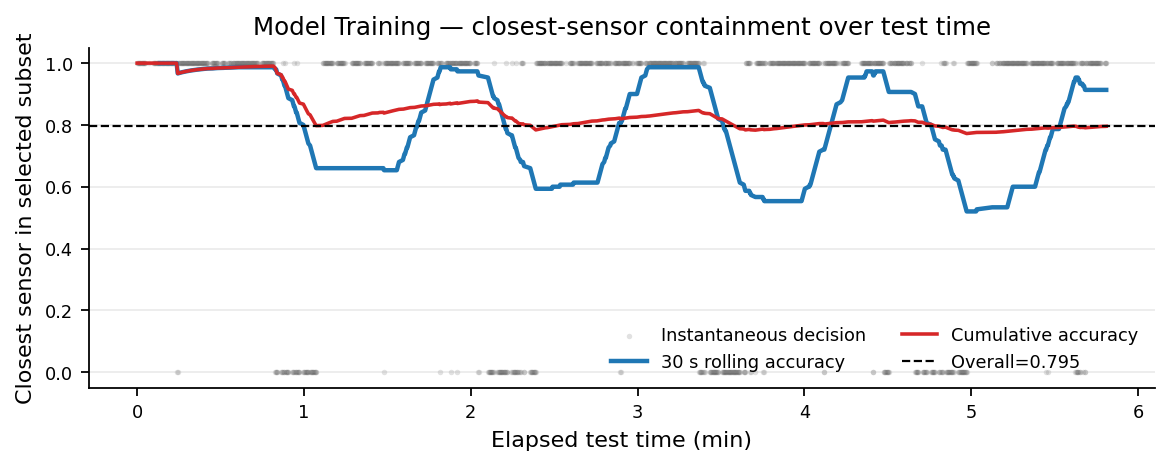

saved /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/figures/cell3_full_time_rolling_closest_accuracy.pdf
saved /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/figures/cell3_full_time_rolling_closest_accuracy.png


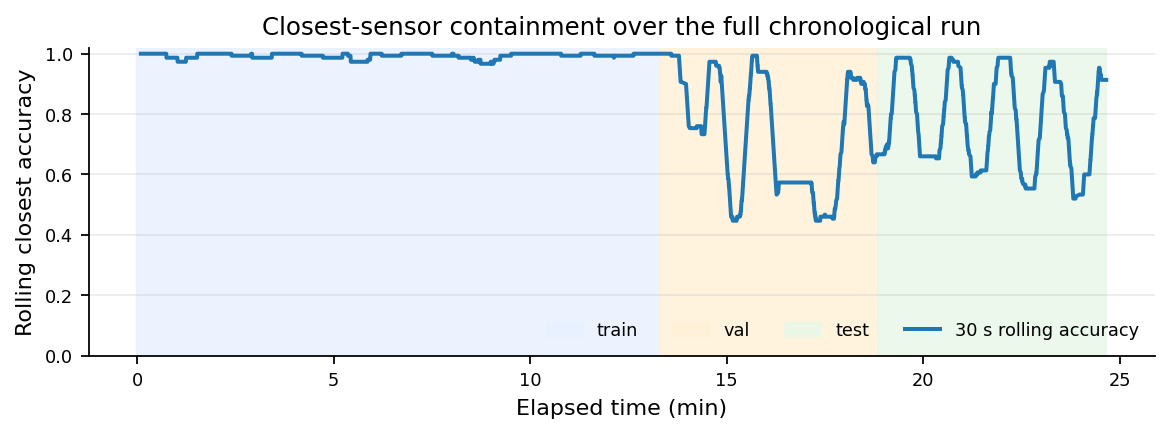

saved /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/figures/cell3_split_metric_bars.pdf
saved /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/figures/cell3_split_metric_bars.png


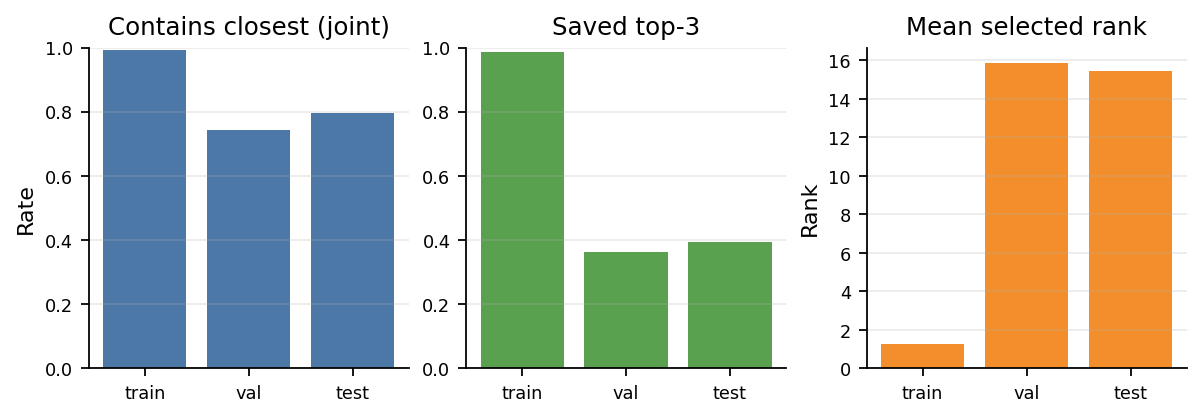

saved /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/figures/cell3_validation_history.pdf
saved /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/figures/cell3_validation_history.png


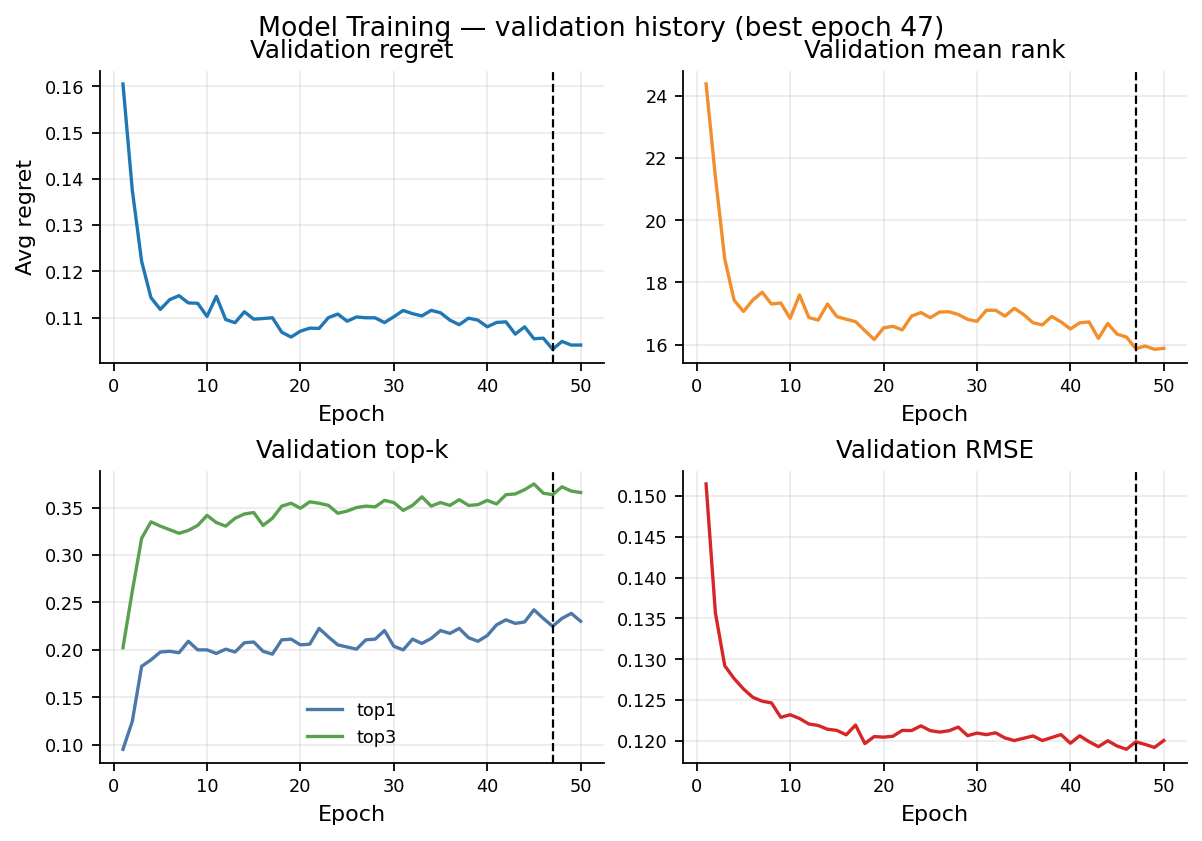

saved /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/figures/cell3_test_rank_regret_distributions.pdf
saved /Users/kyle/Documents/GitHub/TwoTowerSensorRec/experiments/static_action_two_tower/static_action_saved_h512_d2_e16_lr5e4_multi/figures/cell3_test_rank_regret_distributions.png


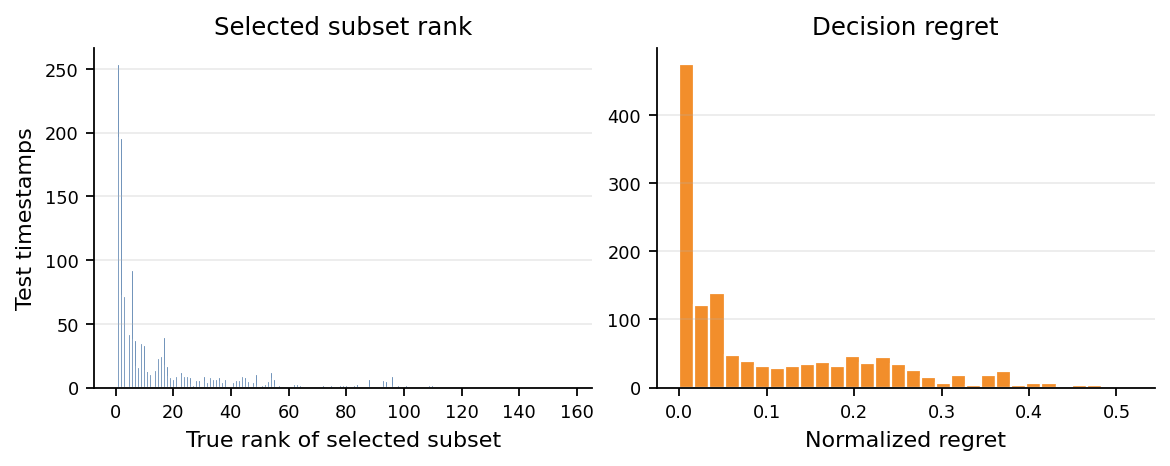

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update(
    {
        "figure.dpi": 160,
        "savefig.dpi": 600,
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


def save_paper_fig(fig, name: str) -> None:
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight", dpi=600)
    print("saved", pdf_path)
    print("saved", png_path)


dt_seconds = float(per_time_df["datetime"].sort_values().diff().dt.total_seconds().median())
window_seconds = 30.0
window_n = max(5, int(round(window_seconds / max(dt_seconds, 1e-6))))

# Test-only time vs closest-sensor containment accuracy.
test_time = per_time_df[per_time_df["split"].eq("test")].copy().sort_values("datetime")
test_time["test_elapsed_min"] = (test_time["datetime"] - test_time["datetime"].min()).dt.total_seconds() / 60.0
test_time["rolling_contains_closest"]    = test_time["contains_closest"].rolling(window_n, min_periods=max(5, window_n // 5)).mean()
test_time["cumulative_contains_closest"] = test_time["contains_closest"].expanding().mean()
overall_test_rate = float(test_time["contains_closest"].mean())

fig, ax = plt.subplots(figsize=(7.2, 2.8), constrained_layout=True)
ax.scatter(
    test_time["test_elapsed_min"],
    test_time["contains_closest"],
    s=6, alpha=0.18, color="0.35", linewidths=0, label="Instantaneous decision",
)
ax.plot(test_time["test_elapsed_min"], test_time["rolling_contains_closest"], color="#1f77b4", lw=2.0, label="30 s rolling accuracy")
ax.plot(test_time["test_elapsed_min"], test_time["cumulative_contains_closest"], color="#d62728", lw=1.6, label="Cumulative accuracy")
ax.axhline(overall_test_rate, color="black", lw=1.0, ls="--", label=f"Overall={overall_test_rate:.3f}")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Elapsed test time (min)")
ax.set_ylabel("Closest sensor in selected subset")
ax.set_title("Model Training — closest-sensor containment over test time")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="lower right", ncol=2, frameon=False)
save_paper_fig(fig, "cell3_test_time_vs_closest_accuracy")
plt.show()

# Full chronological view with split boundaries.
timeline = per_time_df.copy().sort_values("datetime")
timeline["rolling_contains_closest"] = timeline["contains_closest"].rolling(window_n, min_periods=max(5, window_n // 5)).mean()
fig, ax = plt.subplots(figsize=(7.2, 2.6), constrained_layout=True)
split_colors = {"train": "#e8f1ff", "val": "#fff1d6", "test": "#e8f7e8"}
for split_name, g in timeline.groupby("split", sort=False):
    ax.axvspan(g["elapsed_min"].min(), g["elapsed_min"].max(), color=split_colors.get(split_name, "0.95"), alpha=0.8, label=split_name)
ax.plot(timeline["elapsed_min"], timeline["rolling_contains_closest"], color="#1f77b4", lw=1.8, label="30 s rolling accuracy")
ax.set_ylim(0.0, 1.02)
ax.set_xlabel("Elapsed time (min)")
ax.set_ylabel("Rolling closest accuracy")
ax.set_title("Closest-sensor containment over the full chronological run")
handles, labels = ax.get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
ax.legend([h for h, _ in unique], [l for _, l in unique], loc="lower right", ncol=4, frameon=False)
ax.grid(True, axis="y", alpha=0.25)
save_paper_fig(fig, "cell3_full_time_rolling_closest_accuracy")
plt.show()

# Split comparison bars.
plot_summary = (
    split_summary_df.set_index("split")
    .reindex(["train", "val", "test"])
    .dropna(how="all")
    .reset_index()
)
fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.5), constrained_layout=True)
bar_color = "#4c78a8"
axes[0].bar(plot_summary["split"], plot_summary["contains_closest"], color=bar_color)
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Contains closest (joint)")
axes[0].set_ylabel("Rate")
axes[1].bar(plot_summary["split"], plot_summary["saved_top3"], color="#59a14f")
axes[1].set_ylim(0, 1.0)
axes[1].set_title("Saved top-3")
axes[2].bar(plot_summary["split"], plot_summary["mean_rank"], color="#f28e2b")
axes[2].set_title("Mean selected rank")
axes[2].set_ylabel("Rank")
for ax in axes:
    ax.grid(True, axis="y", alpha=0.25)
save_paper_fig(fig, "cell3_split_metric_bars")
plt.show()

# Training history — read directly from the in-memory result dict.
history_df = result["history"]
best_epoch = int(best_info["best_epoch"])
fig, axes = plt.subplots(2, 2, figsize=(7.4, 5.0), constrained_layout=True)
axes = axes.ravel()
axes[0].plot(history_df["epoch"], history_df["val_avg_regret"], color="#1f77b4")
axes[0].set_title("Validation regret")
axes[0].set_ylabel("Avg regret")
axes[1].plot(history_df["epoch"], history_df["val_mean_rank"], color="#f28e2b")
axes[1].set_title("Validation mean rank")
axes[2].plot(history_df["epoch"], history_df["val_top1"], label="top1", color="#4c78a8")
axes[2].plot(history_df["epoch"], history_df["val_top3"], label="top3", color="#59a14f")
axes[2].set_title("Validation top-k")
axes[2].legend(frameon=False)
axes[3].plot(history_df["epoch"], history_df["val_rmse"], color="#d62728")
axes[3].set_title("Validation RMSE")
for ax in axes:
    ax.axvline(best_epoch, color="black", lw=1.0, ls="--")
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.25)
fig.suptitle(f"Model Training — validation history (best epoch {best_epoch})", y=1.02)
save_paper_fig(fig, "cell3_validation_history")
plt.show()

# Test rank/regret distributions.
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), constrained_layout=True)
rank_bins = np.arange(0.5, per_time_df["saved_rank"].max() + 1.5, 1.0)
axes[0].hist(test_time["saved_rank"], bins=rank_bins, color="#4c78a8", edgecolor="white")
axes[0].set_xlabel("True rank of selected subset")
axes[0].set_ylabel("Test timestamps")
axes[0].set_title("Selected subset rank")
axes[1].hist(test_time["norm_regret"], bins=30, color="#f28e2b", edgecolor="white")
axes[1].set_xlabel("Normalized regret")
axes[1].set_title("Decision regret")
for ax in axes:
    ax.grid(True, axis="y", alpha=0.25)
save_paper_fig(fig, "cell3_test_rank_regret_distributions")
plt.show()

# ── Multi-vehicle accuracy figures ────────────────────────────────────────────
# Only rendered when per-vehicle columns were preserved during feature building.
if has_per_vehicle:
    veh_short = {v: "V" + v.replace("vehicle", "") for v in veh_names}
    split_names_avail = [s for s in ["train", "val", "test"] if s in plot_summary["split"].values]
    x = np.arange(len(split_names_avail))

    # ── Figure 1: containment metrics ────────────────────────────────────────
    contain_defs = (
        [("contains_closest_both", "Both vehicles",  "#2ca02c"),
         ("contains_closest_any",  "Either vehicle", "#1f77b4")]
        + [(f"contains_closest_{v}", veh_short[v], c)
           for v, c in zip(veh_names, ["#9467bd", "#8c564b"])]
    )
    contain_defs = [(m, lbl, c) for m, lbl, c in contain_defs if m in plot_summary.columns]
    n_bars = len(contain_defs)
    width  = 0.8 / n_bars

    fig, ax = plt.subplots(figsize=(6.0, 3.0), constrained_layout=True)
    for k, (metric, label, color) in enumerate(contain_defs):
        vals = [float(plot_summary.loc[plot_summary["split"] == s, metric].iloc[0]) for s in split_names_avail]
        ax.bar(x + (k - n_bars / 2 + 0.5) * width, vals, width, label=label, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(split_names_avail)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Rate")
    ax.set_title("Closest-sensor containment — per-vehicle and joint")
    ax.legend(frameon=False, ncol=2)
    ax.grid(True, axis="y", alpha=0.25)
    save_paper_fig(fig, "cell3_multi_vehicle_containment")
    plt.show()

    # ── Figure 2: per-vehicle regret vs joint worst-case regret ──────────────
    regret_defs = [
        (f"avg_regret_{v}", veh_short[v], c)
        for v, c in zip(veh_names, ["#9467bd", "#8c564b"])
        if f"avg_regret_{v}" in plot_summary.columns
    ]
    if "avg_max_vehicle_regret" in plot_summary.columns:
        regret_defs.append(("avg_max_vehicle_regret", "Worst vehicle", "#e45756"))
    if "avg_regret" in plot_summary.columns:
        regret_defs.append(("avg_regret", "Joint avg", "#4c78a8"))

    n_bars2 = len(regret_defs)
    width2  = 0.8 / n_bars2

    fig, ax = plt.subplots(figsize=(6.0, 3.0), constrained_layout=True)
    for k, (metric, label, color) in enumerate(regret_defs):
        vals = [float(plot_summary.loc[plot_summary["split"] == s, metric].iloc[0]) for s in split_names_avail]
        ax.bar(x + (k - n_bars2 / 2 + 0.5) * width2, vals, width2, label=label, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(split_names_avail)
    ax.set_ylabel("Avg regret")
    ax.set_title("Per-vehicle and joint regret")
    ax.legend(frameon=False, ncol=2)
    ax.grid(True, axis="y", alpha=0.25)
    save_paper_fig(fig, "cell3_multi_vehicle_regret")
    plt.show()

    # ── Figure 3: rolling per-vehicle closest-containment over time ──────────
    colors_veh = ["#9467bd", "#8c564b", "#17becf", "#bcbd22"]
    fig, ax = plt.subplots(figsize=(7.2, 2.8), constrained_layout=True)
    for vname, color in zip(veh_names, colors_veh):
        col = f"contains_closest_{vname}"
        if col not in timeline.columns:
            continue
        rolling = timeline[col].rolling(window_n, min_periods=max(5, window_n // 5)).mean()
        ax.plot(timeline["elapsed_min"], rolling, lw=1.8, color=color, label=f"Rolling {veh_short[vname]}")
    if "contains_closest_both" in timeline.columns:
        rolling_both = timeline["contains_closest_both"].rolling(window_n, min_periods=max(5, window_n // 5)).mean()
        ax.plot(timeline["elapsed_min"], rolling_both, lw=2.2, color="#2ca02c", ls="--", label="Rolling both")
    for split_name, g in timeline.groupby("split", sort=False):
        ax.axvspan(g["elapsed_min"].min(), g["elapsed_min"].max(),
                   color=split_colors.get(split_name, "0.95"), alpha=0.3)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel("Elapsed time (min)")
    ax.set_ylabel("Rolling containment rate")
    ax.set_title("Per-vehicle closest-sensor containment over time")
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
    ax.legend([h for h, _ in unique], [l for _, l in unique], frameon=False, ncol=3)
    ax.grid(True, axis="y", alpha=0.25)
    save_paper_fig(fig, "cell3_multi_vehicle_rolling_containment")
    plt.show()

    # ── Figure 4: per-vehicle norm-regret distributions (test set) ───────────
    n_veh = len(veh_names)
    fig, axes = plt.subplots(1, n_veh + 1, figsize=(3.5 * (n_veh + 1), 2.8), constrained_layout=True)
    for j, (vname, color) in enumerate(zip(veh_names, colors_veh)):
        col = f"norm_regret_{vname}"
        if col in test_time.columns:
            axes[j].hist(test_time[col], bins=30, color=color, edgecolor="white")
            axes[j].set_xlabel("Normalized regret")
            axes[j].set_title(f"Regret — {veh_short[vname]}")
            axes[j].grid(True, axis="y", alpha=0.25)
    if "max_vehicle_norm_regret" in test_time.columns:
        axes[-1].hist(test_time["max_vehicle_norm_regret"], bins=30, color="#e45756", edgecolor="white")
        axes[-1].set_xlabel("Normalized regret")
        axes[-1].set_title("Worst-vehicle regret")
        axes[-1].grid(True, axis="y", alpha=0.25)
    fig.suptitle("Per-vehicle regret distributions (test set)", y=1.02)
    save_paper_fig(fig, "cell3_multi_vehicle_regret_distributions")
    plt.show()
